<a href="https://colab.research.google.com/github/She-Wins/TS_Academy_Capstone_Project/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Predictions

##Problem Type Supervised Learning-Classification

##Business Objective
To predict whether a telecom customer will churn (Yes/No) and identify key drivers of churn in order to support targeted retention strategies.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
df=pd.read_csv("Telco Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [39]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [40]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipython-input-1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [41]:
df.drop("customerID", axis=1, inplace=True)

In [42]:
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [43]:
df=pd.get_dummies(df,drop_first=True)

In [45]:
x=df.drop("Churn", axis=1)
y=df["Churn"]

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.3, stratify=y,random_state=42)

In [46]:
scaler= StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [47]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)

y_pred_log=log_model.predict(x_test_scaled)

Accuracy: 0.8088026502602934
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



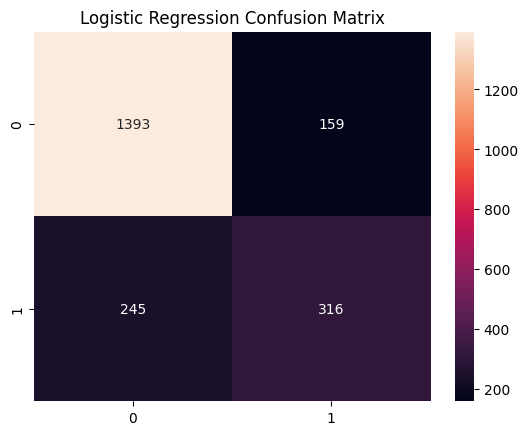

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

cm=confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [52]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf=rf_model.predict (x_test)

Accuracy: 0.7889256980596309
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.63      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



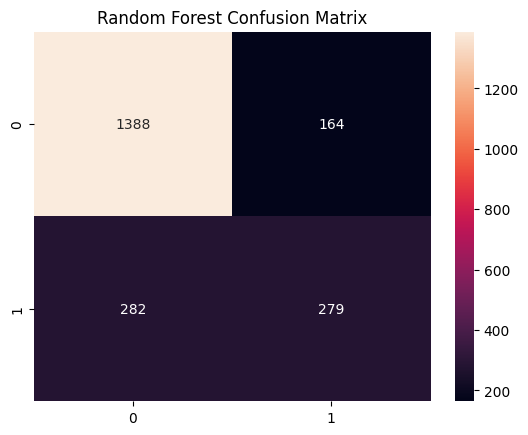

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm=confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [55]:
importances= pd.Series(rf_model.feature_importances_, index=x.columns)
importances.sort_values(ascending=False).head(10)

,0
TotalCharges,0.186119
tenure,0.171801
MonthlyCharges,0.167107
InternetService_Fiber optic,0.038684
PaymentMethod_Electronic check,0.037062
Contract_Two year,0.031502
OnlineSecurity_Yes,0.029808
gender_Male,0.028664
PaperlessBilling_Yes,0.026467
Contract_One year,0.023604


##Key Findings
-Customers on month-to-month contracts show higher churn rates.
-Higher monthly charges are associated with increased churn risk.
-Tenure is negatively correlated with churn (longer tenure=lower churn).

##Business Recommendation
Retention strategies should be focused on:
-Month-to-Month customers
-High monthly charge segments
-New customers (low tenure)